In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm
from matplotlib.dates import DateFormatter, HourLocator, MinuteLocator, num2date, date2num
from scipy.fft import rfft2, fftfreq, rfftfreq

In [ ]:
SCRATCHDIR = "/glade/derecho/scratch/nforcone"

# high model top
RUNDIR_HIGH_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_fadiab_p_pert_isothermal275K/run"
FILENAME_HIGH_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_fadiab_p_pert_isothermal275K.cam.h0i.0001-01-01-00000.nc"

# 12km model top
RUNDIR_LOW_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_400m_fadiab_p_pert_isothermal275K/run"
FILENAME_LOW_TOP = "CAM_6_4_025_20240829_ne30_ne30_mg16_L30_400m_fadiab_p_pert_isothermal275K.cam.h0i.0001-01-01-00000.nc"

# high, dz=400m
RUNDIR_400m_50km = "CAM_6_4_025_20240829_ne30_ne30_mg16_L125_dz400m_50kmTop_fadiab_p_pert_isothermal275K_08day/run"
FILENAME_400m_50km = "CAM_6_4_025_20240829_ne30_ne30_mg16_L125_dz400m_50kmTop_fadiab_p_pert_isothermal275K_08day.cam.h0i.0001-01-01-00000.nc"

ds_high_top = xr.open_dataset(os.path.join(SCRATCHDIR, RUNDIR_HIGH_TOP, FILENAME_HIGH_TOP), decode_cf=False)
ds_low_top = xr.open_dataset(os.path.join(SCRATCHDIR, RUNDIR_LOW_TOP, FILENAME_LOW_TOP), decode_cf=False)
ds_400m_50km = xr.open_dataset(os.path.join(SCRATCHDIR, RUNDIR_400m_50km, FILENAME_400m_50km), decode_cf=False)

In [2]:
def Hovmoller(MyAx, field_DataArray, lat_val, MyCMAP, MyNorm):
    labelsize = 16
    times = field_DataArray.time
    lons = field_DataArray.lon

    field = field_DataArray[:,:, :].sel(lat=lat_val, method="nearest")

    CF = MyAx.pcolormesh(lons, times, field, cmap=MyCMAP, norm=MyNorm)
    cb = plt.colorbar(CF, ax=MyAx)
    cb.set_label(r'Zonal Wind Speed [$m s^{-1}$]', size=labelsize)
    plt.xticks(rotation=45, size='xx-small')
    MyAx.set_xticks(np.arange(0, 361, step=10))
    MyAx.set_xlabel("Longitude", size=labelsize)
    MyAx.yaxis.set_major_locator(HourLocator(interval=3))
    MyAx.yaxis.set_major_formatter(DateFormatter("%d %H:%M"))
    MyAx.set_title(f"lat={field.lat:.2f}", size=labelsize)

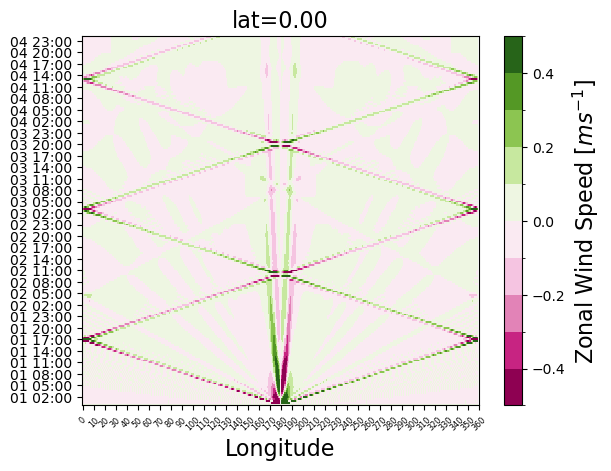

In [3]:
# figure and axes
plt.figure(1)
hovmoller_ax = plt.axes()

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.5, 0.5, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(hovmoller_ax, ds_high_top.U850, lat_value, cmap, norm)

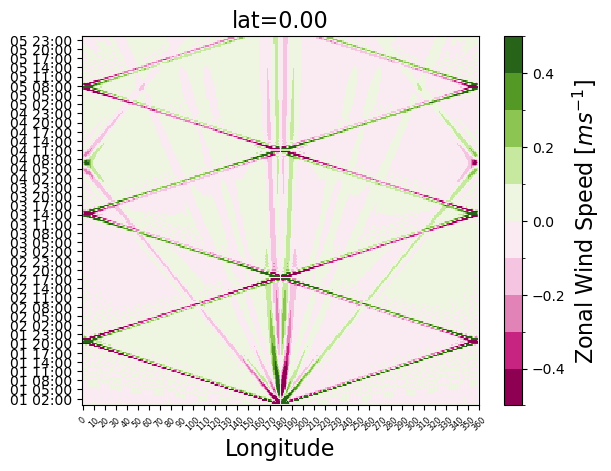

In [4]:
# figure and axes
plt.figure(2)
hovmoller_ax_low = plt.axes()

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.5, 0.5, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(hovmoller_ax_low, ds_low_top.U850, lat_value, cmap, norm)

Num time points:  193
Num grid points:  360
signal_fft.shape:  (193, 181)


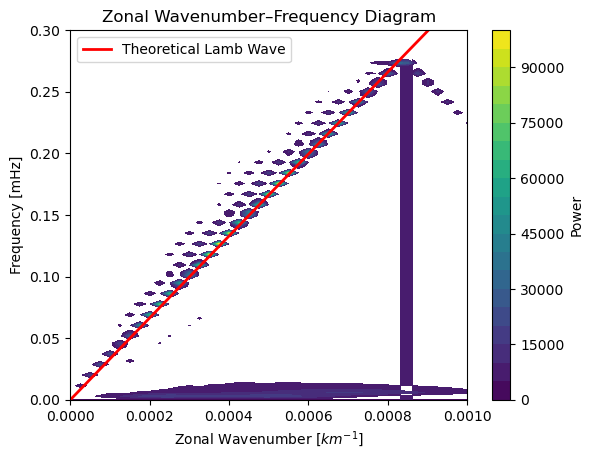

In [5]:
# scipy rfft2: computes 2D FFT of a real-values input signal
# scipy fftfreq: Returns the Discrete Fourier Transform sample frequencies (returns array length n)
# scipy rfftfreq: Return the Discrete Fourier Transform sample frequencies (returns array length n//2 + 1)

# select U at 850 hPa along the Equator
U850 = ds_high_top.U850.sel(lat=0)

# calculate anomalies from time mean to be used as signal for FFT
signal = U850 - U850.mean(dim='time')

# number of time points and number of grid points
nt, nx = signal.shape
print('Num time points: ', nt)
print('Num grid points: ', nx)

dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters

# 2D FFT
signal_fft = rfft2(signal)
print('signal_fft.shape: ', signal_fft.shape)

freq = fftfreq(nt, d=dt)               # s^-1
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1

power = np.abs(signal_fft)**2

# sound speed, isothermal atmosphere
T0 = 275
Rd = 287
cp = 1004
cv = 717
gamma = cp / cv
cs = np.sqrt(gamma * Rd * T0) / 1000  # km s^-1

# Lamb wave dispersion relationship
omega = cs * wavenumber * 1e3         # mHz

# plot
plt.figure(3)
plt.contourf(wavenumber, freq*1e3, power, levels=20)  # plot frequency in mHz
plt.plot(wavenumber, omega, 'r-', label='Theoretical Lamb Wave', linewidth=2)
plt.xlabel(r"Zonal Wavenumber [$km^{-1}$]")
plt.ylabel("Frequency [mHz]")
plt.xlim((0, 0.001))
plt.ylim((0, 0.3))
plt.title("Zonal Wavenumber–Frequency Diagram")
plt.colorbar(label='Power')
plt.legend()
plt.show()

Num time points:  241
Num grid points:  360
signal_fft.shape:  (241, 181)


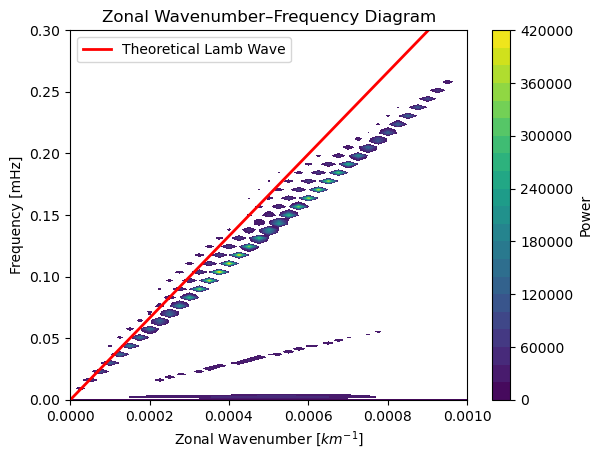

In [6]:
# scipy rfft2: computes 2D FFT of a real-values input signal
# scipy fftfreq: Returns the Discrete Fourier Transform sample frequencies (returns array length n)
# scipy rfftfreq: Return the Discrete Fourier Transform sample frequencies (returns array length n//2 + 1)

# select U at 850 hPa along the Equator
U850 = ds_low_top.U850.sel(lat=0)

# calculate anomalies from time mean to be used as signal for FFT
signal = U850 - U850.mean(dim='time')

# number of time points and number of grid points
nt, nx = signal.shape
print('Num time points: ', nt)
print('Num grid points: ', nx)

dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters

# 2D FFT
signal_fft = rfft2(signal)
print('signal_fft.shape: ', signal_fft.shape)

freq = fftfreq(nt, d=dt)               # s^-1
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1

power = np.abs(signal_fft)**2

# sound speed, isothermal atmosphere
T0 = 275
Rd = 287
cp = 1004
cv = 717
gamma = cp / cv
cs = np.sqrt(gamma * Rd * T0) / 1000  # km s^-1

# Lamb wave dispersion relationship
omega = cs * wavenumber * 1e3         # mHz

# plot
plt.figure(4)
plt.contourf(wavenumber, freq*1e3, power, levels=20)  # plot frequency in mHz
plt.plot(wavenumber, omega, 'r-', label='Theoretical Lamb Wave', linewidth=2)
plt.xlabel(r"Zonal Wavenumber [$km^{-1}$]")
plt.ylabel("Frequency [mHz]")
plt.xlim((0, 0.001))
plt.ylim((0, 0.3))
plt.title("Zonal Wavenumber–Frequency Diagram")
plt.colorbar(label='Power')
plt.legend()
plt.show()

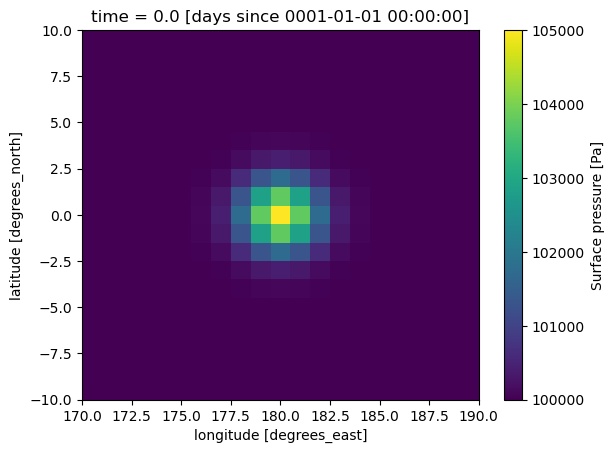

In [7]:
ds_high_top['PS'][0,:,:].plot(xlim=(170, 190), ylim=(-10, 10))

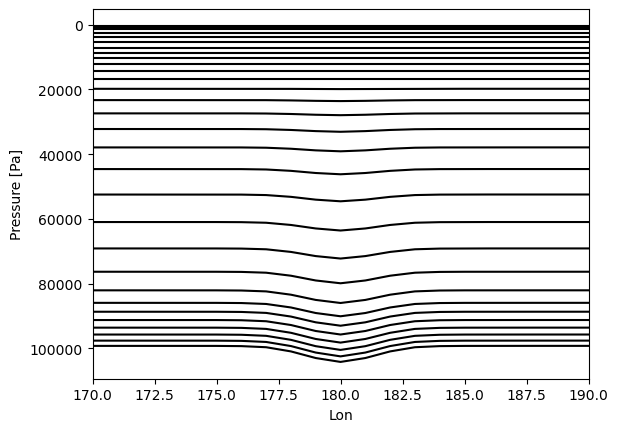

In [8]:
PS_lat0 = ds_high_top['PS'].sel(time=0, lat=0.0)
lon = ds_high_top.lon

# high
hyam_high = ds_high_top['hyam']
hybm_high = ds_high_top['hybm']
lev_high = hyam_high * 100000 + hybm_high * PS_lat0

plt.figure(6)
lev_ax_high = plt.axes()
lev_ax_high.plot(lon, lev_high.values.T, 'k')
lev_ax_high.set_xlim(170, 190)
lev_ax_high.set_xlabel('Lon')
lev_ax_high.set_ylabel('Pressure [Pa]')
lev_ax_high.invert_yaxis()

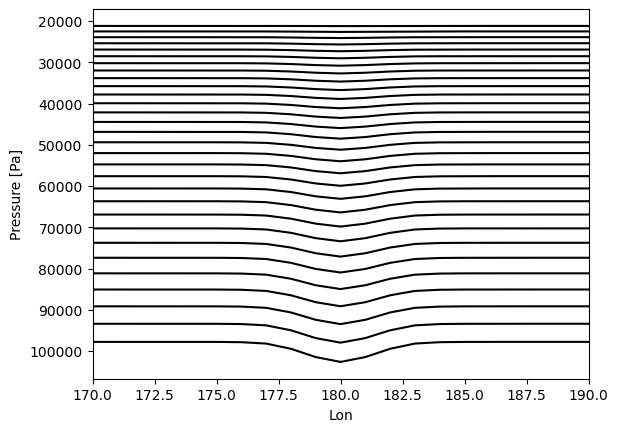

In [9]:
PS_lat0 = ds_low_top['PS'].sel(time=0, lat=0.0)
lon = ds_low_top.lon

# low
hyam_low = ds_low_top['hyam']
hybm_low = ds_low_top['hybm']
lev_low = hyam_low * 100000 + hybm_low * PS_lat0

plt.figure(7)
lev_ax_low = plt.axes()
lev_ax_low.plot(lon, lev_low.values.T, 'k')
lev_ax_low.set_xlim(170, 190)
lev_ax_low.set_xlabel('Lon')
lev_ax_low.set_ylabel('Pressure [Pa]')
lev_ax_low.invert_yaxis()

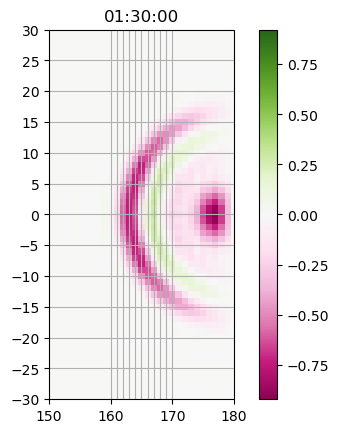

In [10]:
MyProj = ccrs.PlateCarree()

fig, ax = plt.subplots(subplot_kw={'projection': MyProj})

time_ind = 3

xmin, xmax = 150, 180
ymin, ymax = -30, 30

xtick_locs = np.linspace(xmin, xmax, 4)
gl_xtick_locs = (xmin, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, xmax)
ytick_locs = np.linspace(ymin, ymax, 13)

pcmesh = ax.pcolormesh(ds_high_top.lon,
                       ds_high_top.lat,
                       ds_high_top.U850[time_ind], transform=MyProj,
                       cmap='PiYG')
ax.set_extent(([xmin, xmax, ymin, ymax]), crs=MyProj)
ax.set_xticks(xtick_locs, crs=MyProj)
ax.set_yticks(ytick_locs, crs=MyProj)
ax.set_title(num2date(ds_high_top.time)[time_ind].strftime('%H:%M:%S'))
gl = ax.gridlines()
gl.xlocator = mticker.FixedLocator(gl_xtick_locs)
gl.ylocator = mticker.FixedLocator(ytick_locs)
plt.colorbar(pcmesh, ax=ax)

0.26712772516107647


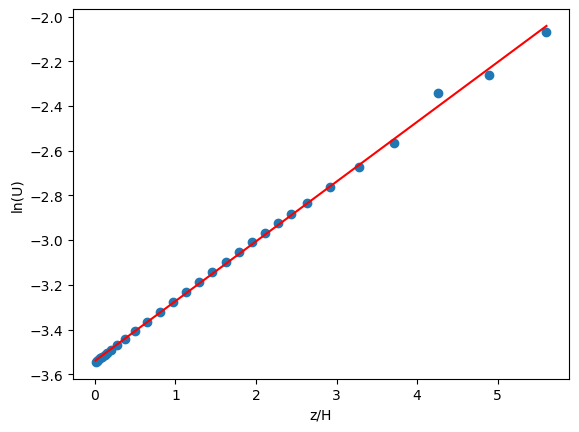

In [11]:
time_ind = 3
lat_val = 0
lon_val = 160

T0 = 275
Rd = 287
g = 9.81

H = (Rd * T0) / g

fig, ax = plt.subplots()

X = ds_high_top.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_high_top.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))

p = np.polyfit(X, Y, 1)

ax.plot(X, X * p[0] + p[1], 'red')

ax.scatter(X, Y)

ax.set_ylabel('ln(U)')
ax.set_xlabel('z/H')

print(p[0])

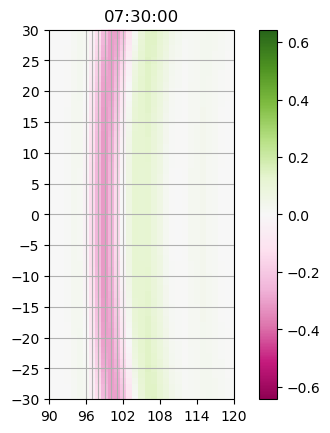

In [12]:
MyProj = ccrs.PlateCarree()

fig, ax = plt.subplots(subplot_kw={'projection': MyProj})

time_ind = 15

xmin, xmax = 90, 120
ymin, ymax = -30, 30

xtick_locs = np.linspace(xmin, xmax, 6)
gl_xtick_locs = ((xmin, 96, 97, 98, 99, 100, 101, 102, xmax))
ytick_locs = np.linspace(ymin, ymax, 13)

ax.set_extent(([xmin, xmax, ymin, ymax]), crs=MyProj)
pcmesh = ax.pcolormesh(ds_high_top.lon,
                       ds_high_top.lat,
                       ds_high_top.U850[time_ind], transform=MyProj,
                       cmap='PiYG')
ax.set_xticks(xtick_locs, crs=MyProj)
ax.set_yticks(ytick_locs, crs=MyProj)
ax.set_title(num2date(ds_high_top.time)[time_ind].strftime('%H:%M:%S'))
gl = ax.gridlines()
gl.xlocator = mticker.FixedLocator(gl_xtick_locs)
gl.ylocator = mticker.FixedLocator(ytick_locs)
plt.colorbar(pcmesh, ax=ax)

0.2672364232813064
-6.467251851542747


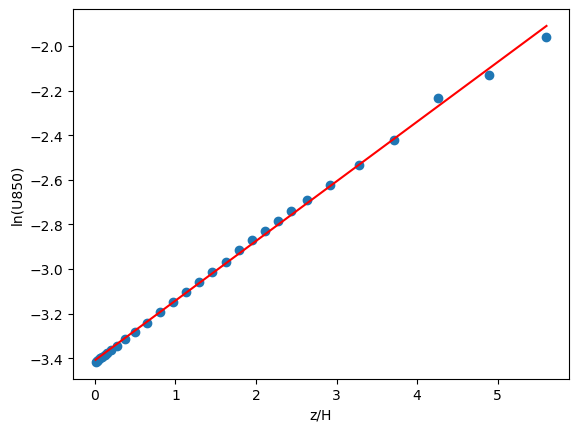

In [13]:
time_ind = 15
lat_val = 0
lon_val = 96

T0 = 275
Rd = 287
g = 9.81

H = (Rd * T0) / g

fig, ax = plt.subplots()

X = ds_high_top.Z3[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest') / H
Y = np.log(abs(ds_high_top.U[time_ind, :, :, :].sel(lat=lat_val, lon=lon_val, method='nearest')))

p = np.polyfit(X, Y, 1)

ax.plot(X, X * p[0] + p[1], 'red')

ax.scatter(X, Y)

ax.set_ylabel('ln(U850)')
ax.set_xlabel('z/H')

theoretical = 2 / 7
print(p[0])
print(((p[0] - theoretical) / (theoretical)) * 100)

(150.0, 210.0)

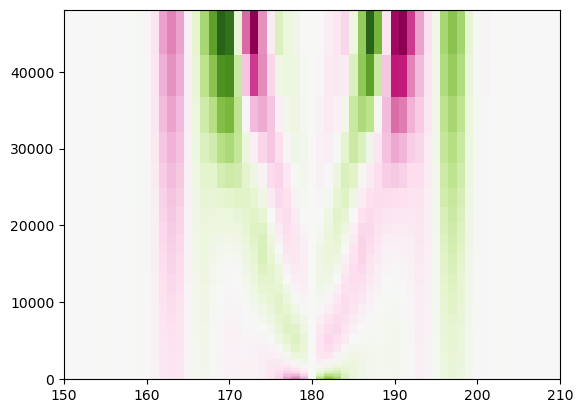

In [14]:
time_ind = 3
lat_val = 0

fig, ax = plt.subplots()

X = ds_high_top.lon.values
Y = ds_high_top.Z3[time_ind, :, :, :].sel(lat=lat_val, method='nearest')
C = ds_high_top.U[time_ind, :, :, :].sel(lat=lat_val, method='nearest')

ax.pcolormesh(X, Y, C, cmap='PiYG')
ax.set_xlim((150, 210))

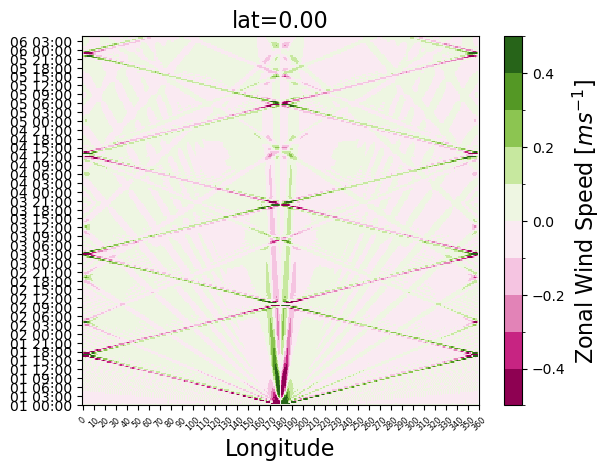

In [15]:
# figure and axes
fig, ax = plt.subplots()

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.5, 0.5, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N, clip=True)

Hovmoller(ax, ds_400m_50km.U850, lat_value, cmap, norm)

# L93

In [8]:
import datetime

In [9]:
def Hovmoller2(MyAx, field_DataArray, lat_val, MyCMAP, MyNorm, clevels, titlestr=""):
    labelsize = 16
    times = field_DataArray.time
    lons = field_DataArray.lon

    field = field_DataArray[:,:, :].sel(lat=lat_val, method="nearest")

    CF = MyAx.pcolormesh(lons, times, field, cmap=MyCMAP, norm=MyNorm)
    cb = plt.colorbar(CF, ax=MyAx, extend='both', ticks=clevels)
    cb.set_label(r'Zonal Wind Speed at 850 hPa [$m s^{-1}$]', size=labelsize)
    plt.xticks(rotation=45, size='small')
    MyAx.set_xticks(np.arange(0, 361, step=10))
    MyAx.set_xlabel("Longitude", size=labelsize)
    MyAx.yaxis.set_major_locator(HourLocator(interval=1))
    MyAx.yaxis.set_minor_locator(MinuteLocator(interval=30))
    MyAx.yaxis.set_major_formatter(DateFormatter("%d %H:%M"))
    MyAx.yaxis.set_minor_formatter(DateFormatter("%M"))
    MyAx.set_ylim((datetime.datetime(1970, 1, 1, 0, 0, tzinfo=datetime.timezone.utc),
                   datetime.datetime(1970, 1, 1, 19, 30, tzinfo=datetime.timezone.utc)))
    MyAx.set_title(f"lat={field.lat:.2f}\n{titlestr}", size=labelsize)

In [136]:
# 86 km top, dz=500m
RUNDIR_500m_86km = "/glade/derecho/scratch/nforcone/CAM_6_4_025_20240829_ne30_ne30_mg16_L93_dz500m_86kmTop_fadiab_p_pert_isothermal275K/run"
FILENAME_500m_86km = "CAM_6_4_025_20240829_ne30_ne30_mg16_L93_dz500m_86kmTop_fadiab_p_pert_isothermal275K.cam.h0i.0001-01-01-00000.nc"

ds_86km_top = xr.open_dataset(os.path.join(SCRATCHDIR, RUNDIR_500m_86km, FILENAME_500m_86km), decode_cf=False)

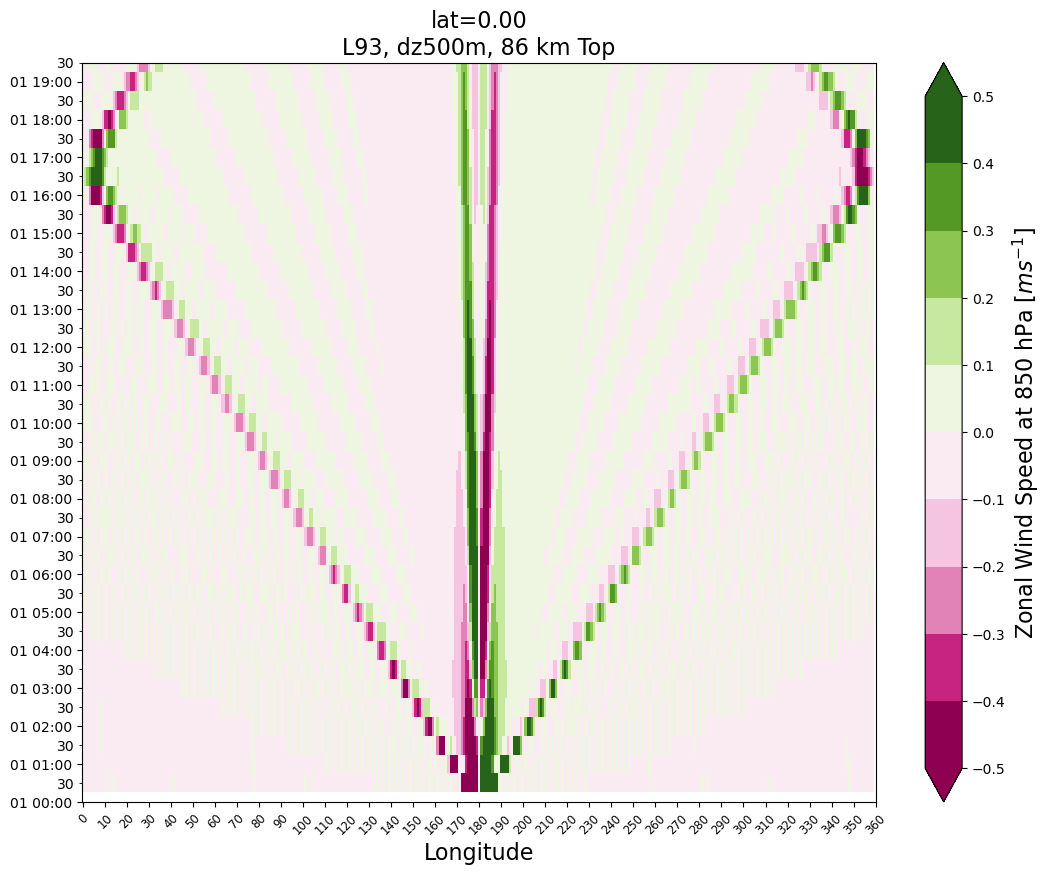

In [137]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.5, 0.5, num=11)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller2(ax, ds_86km_top.U850[1:40, :, :], lat_value, cmap, norm, clevels, "L93, dz500m, 86 km Top")

[-0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4  0.5]


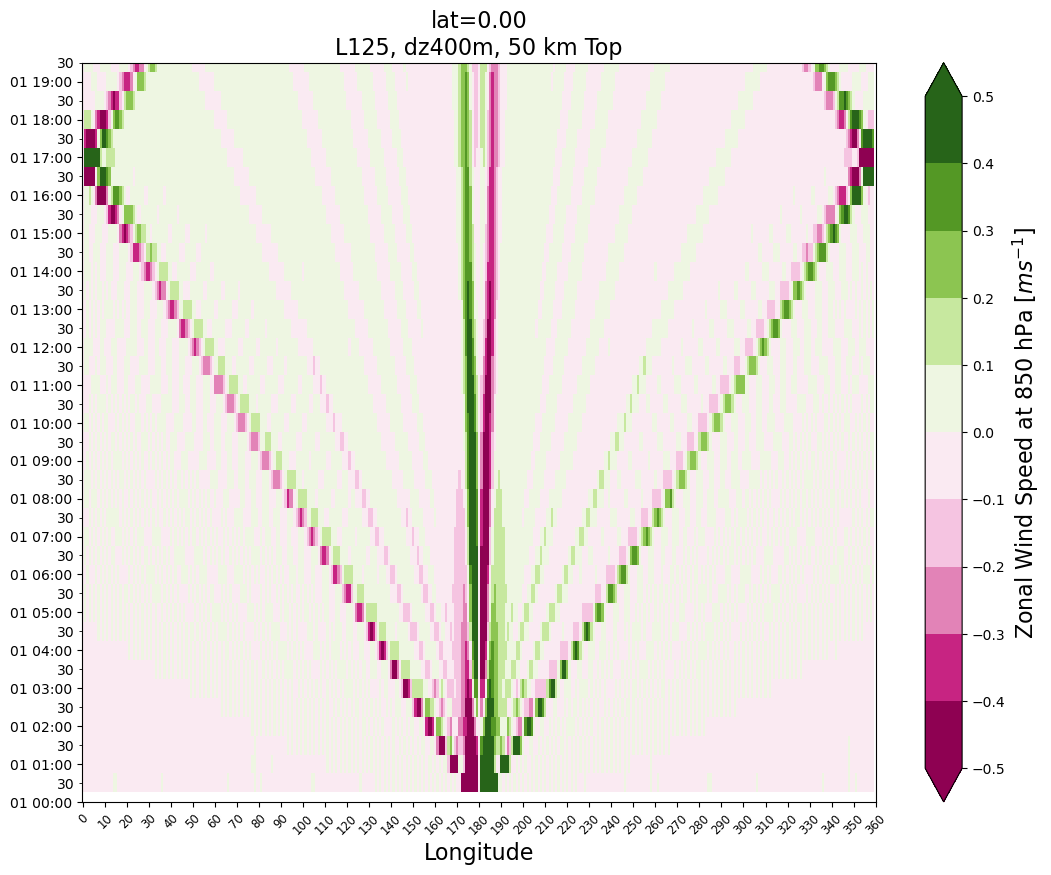

In [139]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.5, 0.5, num=11)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller2(ax, ds_400m_50km.U850[1:40, :, :], lat_value, cmap, norm, clevels, "L125, dz400m, 50 km Top")

In [90]:
ds_86km_top.U850[1:40, :, :].time

<xarray.DataArray 'time' (time: 39)> Size: 312B
array([0.020833, 0.041667, 0.0625  , 0.083333, 0.104167, 0.125   , 0.145833,
       0.166667, 0.1875  , 0.208333, 0.229167, 0.25    , 0.270833, 0.291667,
       0.3125  , 0.333333, 0.354167, 0.375   , 0.395833, 0.416667, 0.4375  ,
       0.458333, 0.479167, 0.5     , 0.520833, 0.541667, 0.5625  , 0.583333,
       0.604167, 0.625   , 0.645833, 0.666667, 0.6875  , 0.708333, 0.729167,
       0.75    , 0.770833, 0.791667, 0.8125  ])
Coordinates:
  * time     (time) float64 312B 0.02083 0.04167 0.0625 ... 0.7708 0.7917 0.8125
Attributes:
    long_name:  time
    units:      days since 0001-01-01 00:00:00
    calendar:   noleap
    bounds:     time_bounds

In [91]:
num2date(ds_86km_top.U850[1:40, :, :].time)

[datetime.datetime(1970, 1, 1, 0, 30, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 1, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 1, 30, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 2, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 2, 30, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 3, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 3, 30, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 4, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 4, 30, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 5, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 5, 30, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 6, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 6, 30, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 7, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(1970, 1, 1, 7, 30, tzi

In [14]:
def Hovmoller3(MyAx, field_DataArray, lat_val, MyCMAP, MyNorm, clevels, titlestr="", fieldlabel=r'Zonal Wind Speed at 850 hPa [$m s^{-1}$]'):
    labelsize = 16
    times = field_DataArray.time
    lons = field_DataArray.lon

    field = field_DataArray[:,:, :].sel(lat=lat_val, method="nearest")

    CF = MyAx.pcolormesh(lons, times, field, cmap=MyCMAP, norm=MyNorm)
    cb = plt.colorbar(CF, ax=MyAx, extend='both', ticks=clevels)
    cb.set_label(fieldlabel, size=labelsize)
    plt.xticks(rotation=45, size='small')
    MyAx.set_xticks(np.arange(0, 361, step=10))
    MyAx.set_xlabel("Longitude", size=labelsize)
    MyAx.yaxis_date()
    MyAx.yaxis.set_major_locator(HourLocator(interval=6))
#    MyAx.yaxis.set_minor_locator(MinuteLocator(interval=30))
    MyAx.yaxis.set_major_formatter(DateFormatter("%d %H:%M"))
#    MyAx.yaxis.set_minor_formatter(DateFormatter("%M"))
    MyAx.set_title(f"lat={field.lat:.2f}\n{titlestr}", size=labelsize)

In [3]:
cjablono_scratch = '/glade/derecho/scratch/cjablono/'
L32_no_diffusion_f = 'cesm2.1.5_03052026.EULT85.L32.fadiab.acid.cos.300K/run/diffusion_0/cesm2.1.5_03052026.EULT85.L32.fadiab.acid.cos.300K.cam.h1.0001-01-01-00000.nc'
L32_diffusion_default_f = 'cesm2.1.5_03052026.EULT85.L32.fadiab.acid.cos.300K/run/diffusion_default/cesm2.1.5_03052026.EULT85.L32.fadiab.acid.cos.300K.cam.h1.0001-01-01-00000.nc'
L93_no_diffusion_f = 'cesm2.1.5_03052026.EULT85.L93.fadiab.acid.cos.300K/run/diffusion_0/cesm2.1.5_03052026.EULT85.L93.fadiab.acid.cos.300K.cam.h1.0001-01-01-00000.nc'
L93_diffusion_default_f = 'cesm2.1.5_03052026.EULT85.L93.fadiab.acid.cos.300K/run/diffusion_default/cesm2.1.5_03052026.EULT85.L93.fadiab.acid.cos.300K.cam.h1.0001-01-01-00000.nc'

L32_no_diffusion = xr.open_dataset(os.path.join(cjablono_scratch, L32_no_diffusion_f), decode_cf=False)
L32_diffusion_default = xr.open_dataset(os.path.join(cjablono_scratch, L32_diffusion_default_f), decode_cf=False)
L93_no_diffusion = xr.open_dataset(os.path.join(cjablono_scratch, L93_no_diffusion_f), decode_cf=False)
L93_diffusion_default = xr.open_dataset(os.path.join(cjablono_scratch, L93_diffusion_default_f), decode_cf=False)

In [4]:
L32_no_diffusion.U850

<xarray.DataArray 'U850' (time: 865, lat: 128, lon: 256)> Size: 113MB
[28344320 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 1kB -88.93 -87.54 -86.14 -84.74 ... 86.14 87.54 88.93
  * lon      (lon) float64 2kB 0.0 1.406 2.812 4.219 ... 354.4 355.8 357.2 358.6
  * time     (time) float64 7kB 0.0 0.006944 0.01389 0.02083 ... 5.986 5.993 6.0
Attributes:
    units:      m/s
    long_name:  Zonal wind at 850 mbar pressure surface

[-0.1  -0.08 -0.06 -0.04 -0.02  0.    0.02  0.04  0.06  0.08  0.1 ]


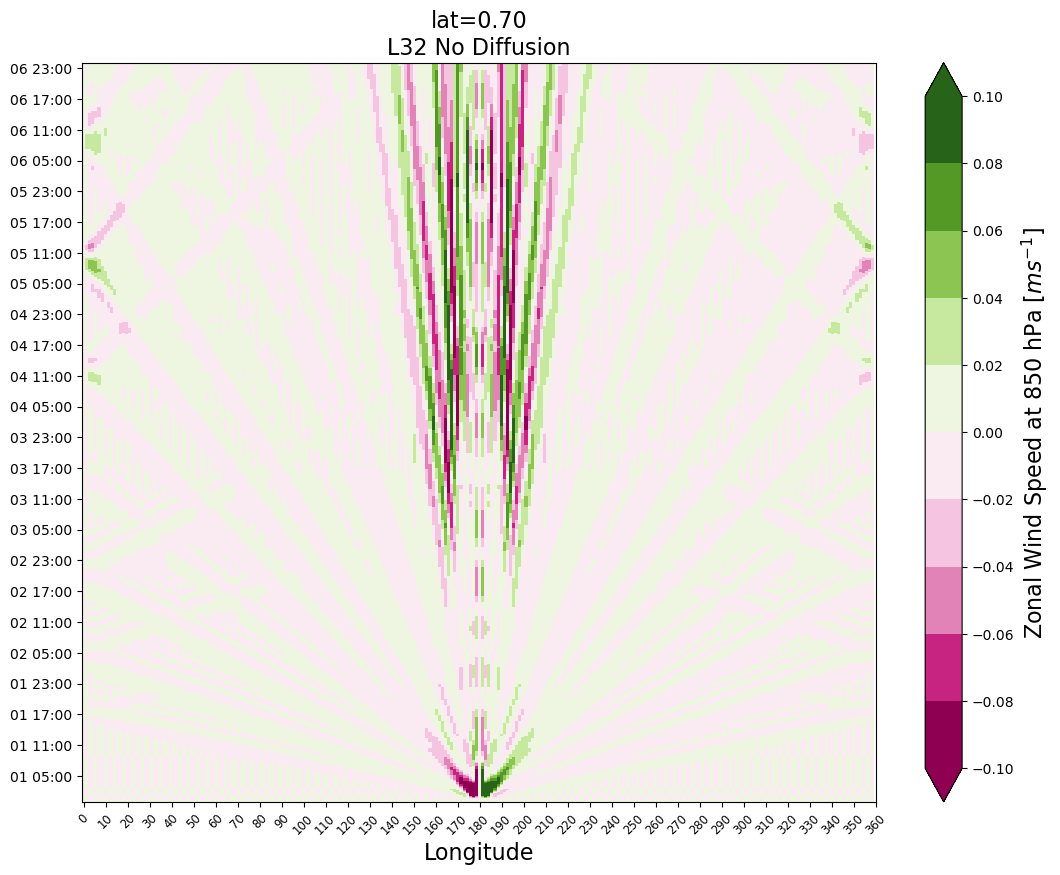

In [22]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.1, 0.1, num=11)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller3(ax, L32_no_diffusion.U850, lat_value, cmap, norm, clevels, "L32 No Diffusion")

[-0.1  -0.08 -0.06 -0.04 -0.02  0.    0.02  0.04  0.06  0.08  0.1 ]


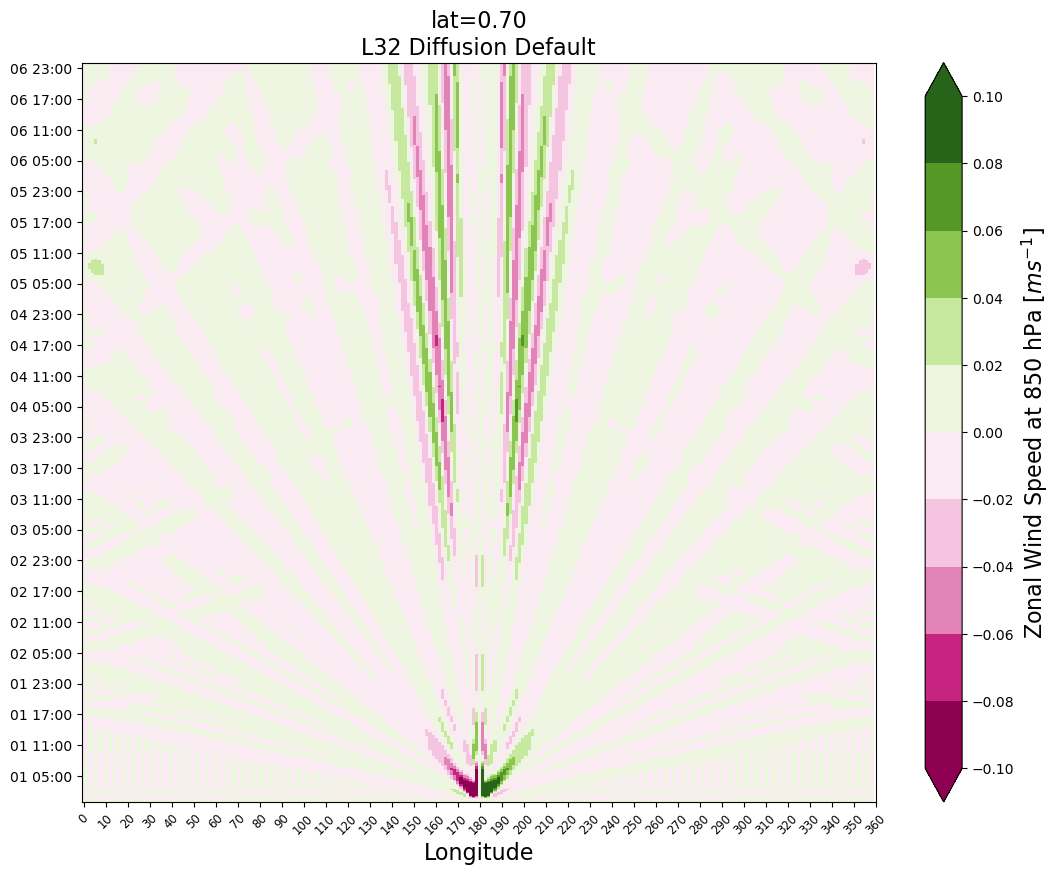

In [24]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.1, 0.1, num=11)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller3(ax, L32_diffusion_default.U850, lat_value, cmap, norm, clevels, "L32 Diffusion Default")

[-0.1  -0.08 -0.06 -0.04 -0.02  0.    0.02  0.04  0.06  0.08  0.1 ]


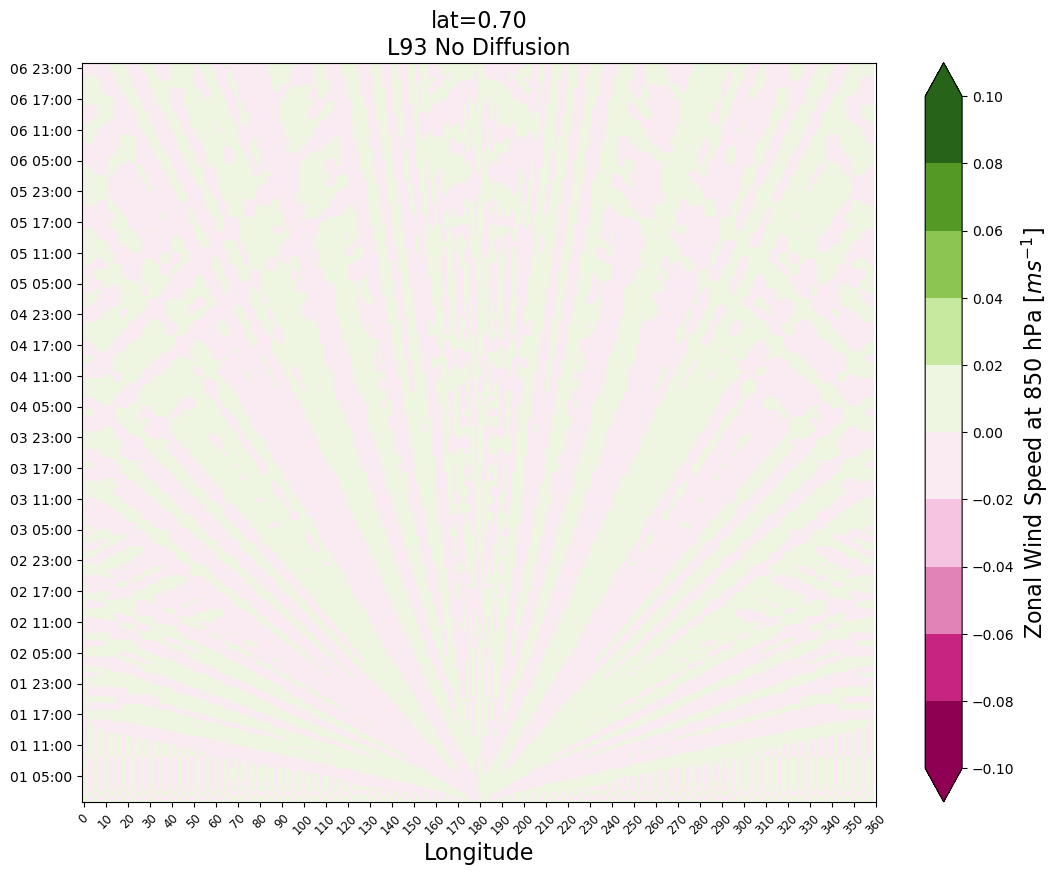

In [25]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.1, 0.1, num=11)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller3(ax, L93_no_diffusion.U850, lat_value, cmap, norm, clevels, "L93 No Diffusion")

[-0.002  -0.0015 -0.001  -0.0005  0.      0.0005  0.001   0.0015  0.002 ]


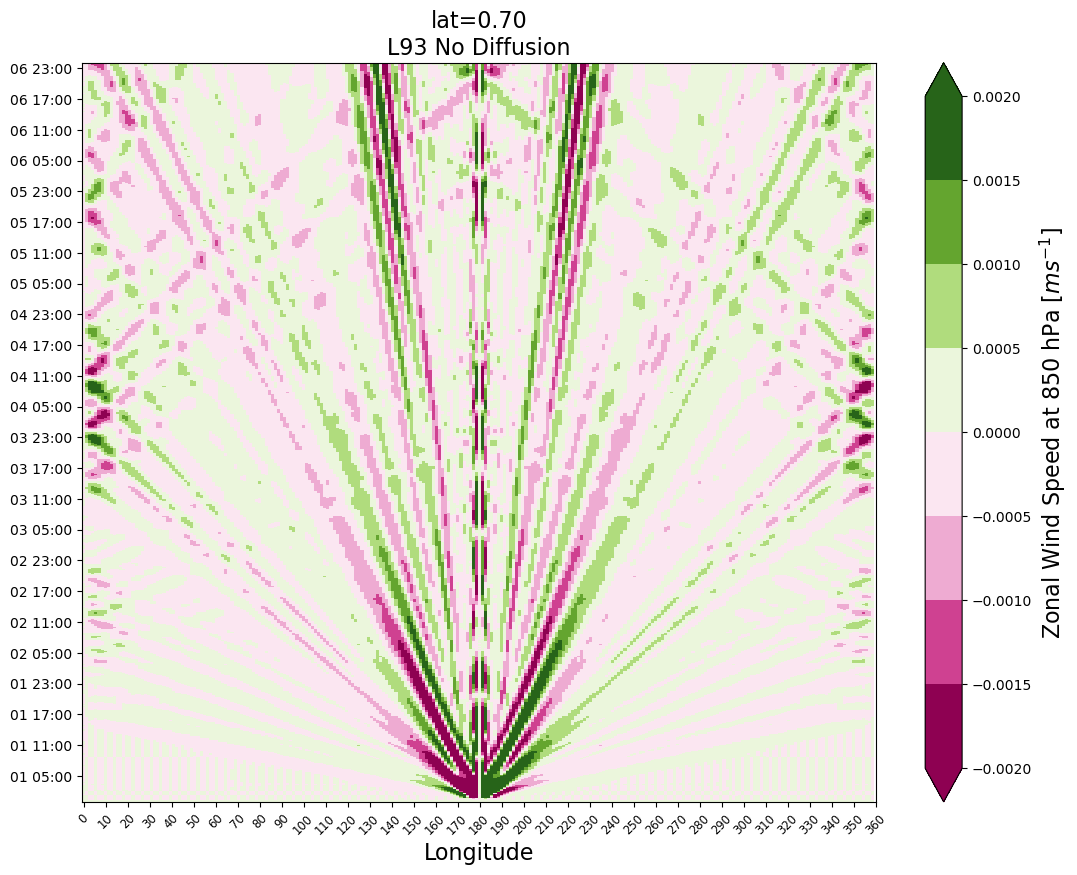

In [18]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.002, 0.002, num=9)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller3(ax, L93_no_diffusion.U850, lat_value, cmap, norm, clevels, "L93 No Diffusion")

[-0.1  -0.08 -0.06 -0.04 -0.02  0.    0.02  0.04  0.06  0.08  0.1 ]


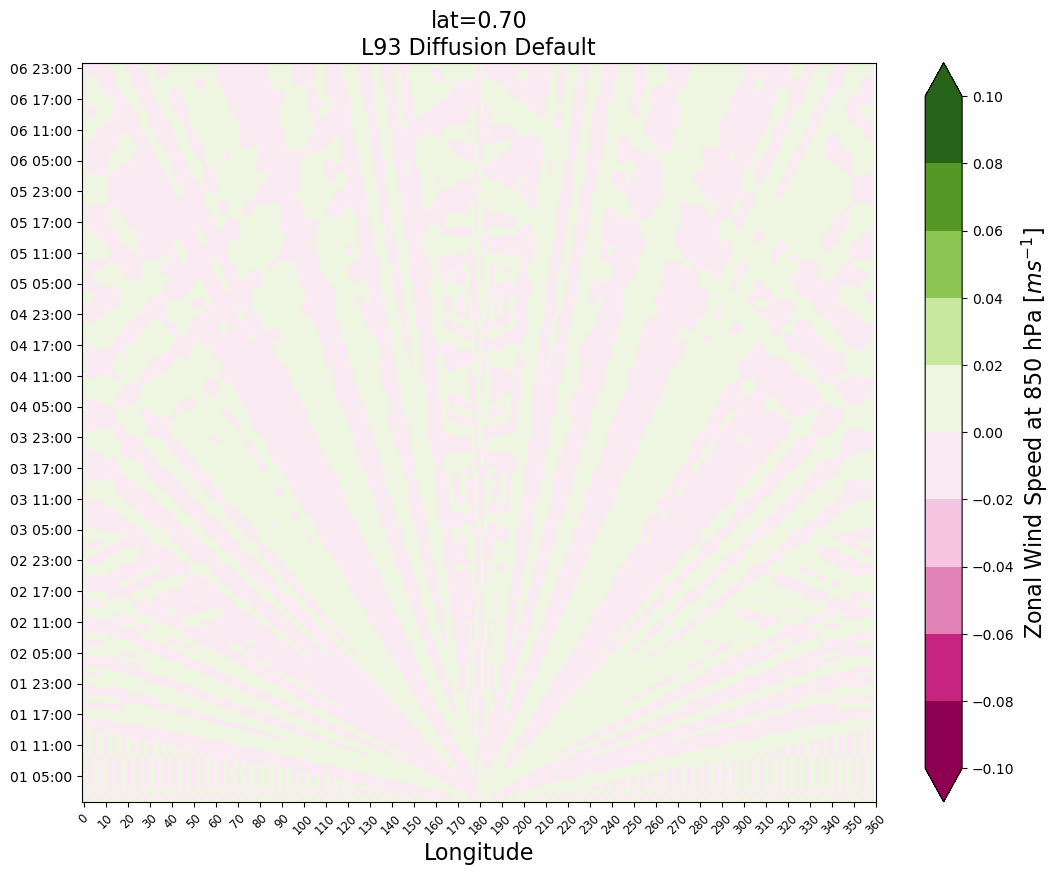

In [83]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.1, 0.1, num=11)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller3(ax, L93_diffusion_default.U850, lat_value, cmap, norm, clevels, "L93 Diffusion Default")

[-0.002  -0.0015 -0.001  -0.0005  0.      0.0005  0.001   0.0015  0.002 ]


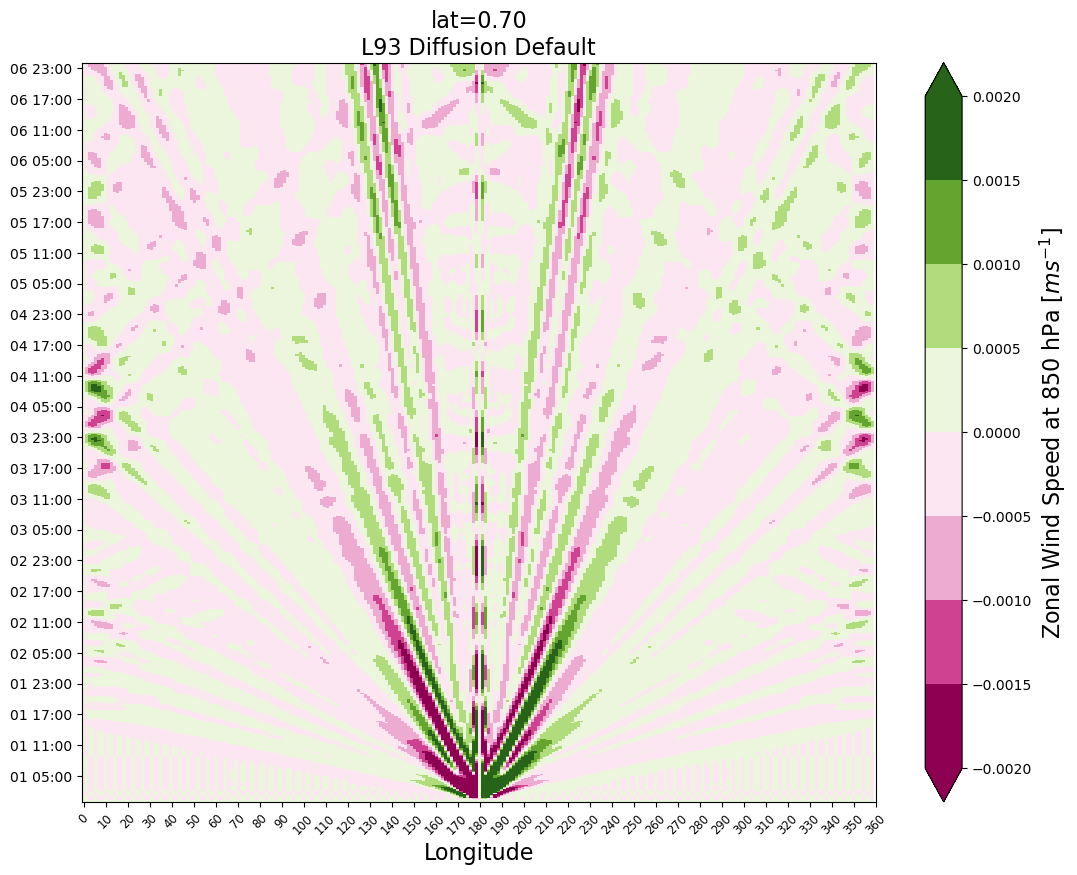

In [86]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.002, 0.002, num=9)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller3(ax, L93_diffusion_default.U850, lat_value, cmap, norm, clevels, "L93 Diffusion Default")

# OMEGA850

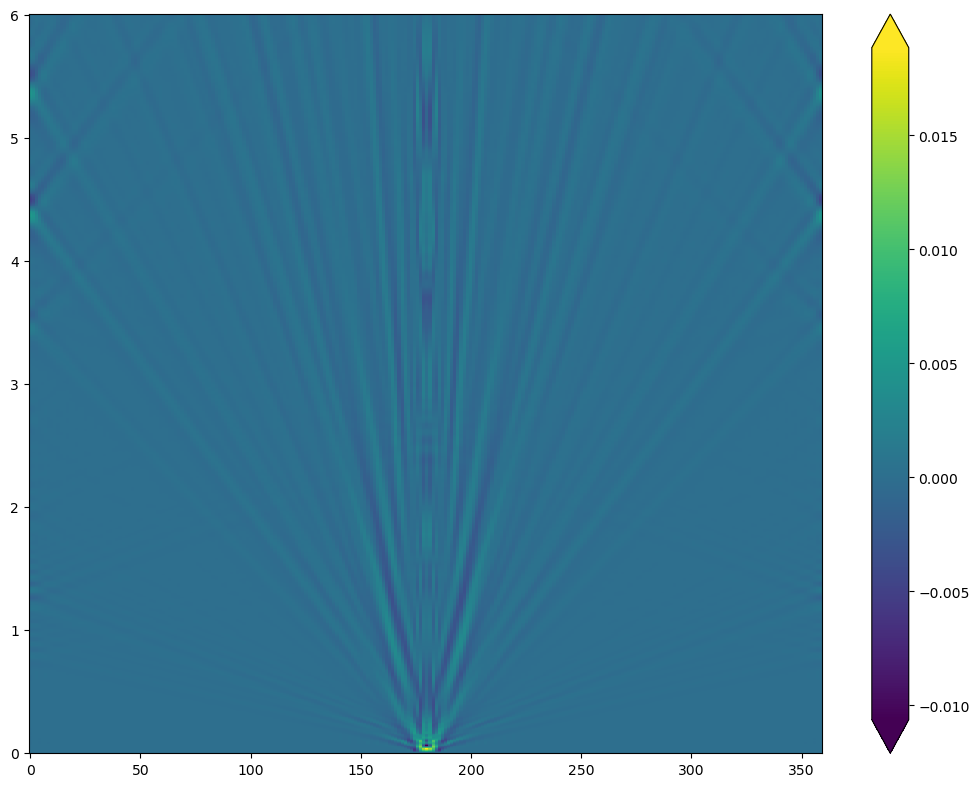

In [19]:
fig, ax = plt.subplots(figsize=(12.8, 9.6))

CFtest = ax.pcolormesh(L32_no_diffusion.lon, L32_no_diffusion.time, L32_no_diffusion.OMEGA850.sel(lat=0, method='nearest'))
cbtest = plt.colorbar(CFtest, ax=ax, extend='both')

In [46]:
L32_no_diffusion

<xarray.Dataset> Size: 680MB
Dimensions:       (lat: 128, lon: 256, lev: 32, ilev: 33, time: 865, nbnd: 2,
                   chars: 8)
Coordinates:
  * lat           (lat) float64 1kB -88.93 -87.54 -86.14 ... 86.14 87.54 88.93
  * lon           (lon) float64 2kB 0.0 1.406 2.812 4.219 ... 355.8 357.2 358.6
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) float64 7kB 0.0 0.006944 0.01389 ... 5.986 5.993 6.0
Dimensions without coordinates: nbnd, chars
Data variables: (12/34)
    ntrk          int32 4B ...
    ntrn          int32 4B ...
    ntrm          int32 4B ...
    gw            (lat) float64 1kB ...
    hyam          (lev) float64 256B ...
    hybm          (lev) float64 256B ...
    ...            ...
    OMEGA850      (time, lat, lon) float32 113MB ...
    PHIS          (time, lat, lon) float32 113MB ...
    PS            (time, lat, lon) float32 113MB ...
    T850          (time, lat, lon) float32 113MB ...
    U850          (time, lat, lon) float32 113MB ...
    V850          (time, lat, lon) float32 113MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              cesm2.1.5_03052026.EULT85.L32.fadiab.acid.cos.300K
    logname:           cjablono
    host:              derecho7
    initial_file:      /glade/u/home/cjablono/CESM_vertical_grids/cam_vcoords...
    topography_file:   bnd_topo
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  minute_10

[-0.01  -0.008 -0.006 -0.004 -0.002  0.     0.002  0.004  0.006  0.008
  0.01 ]


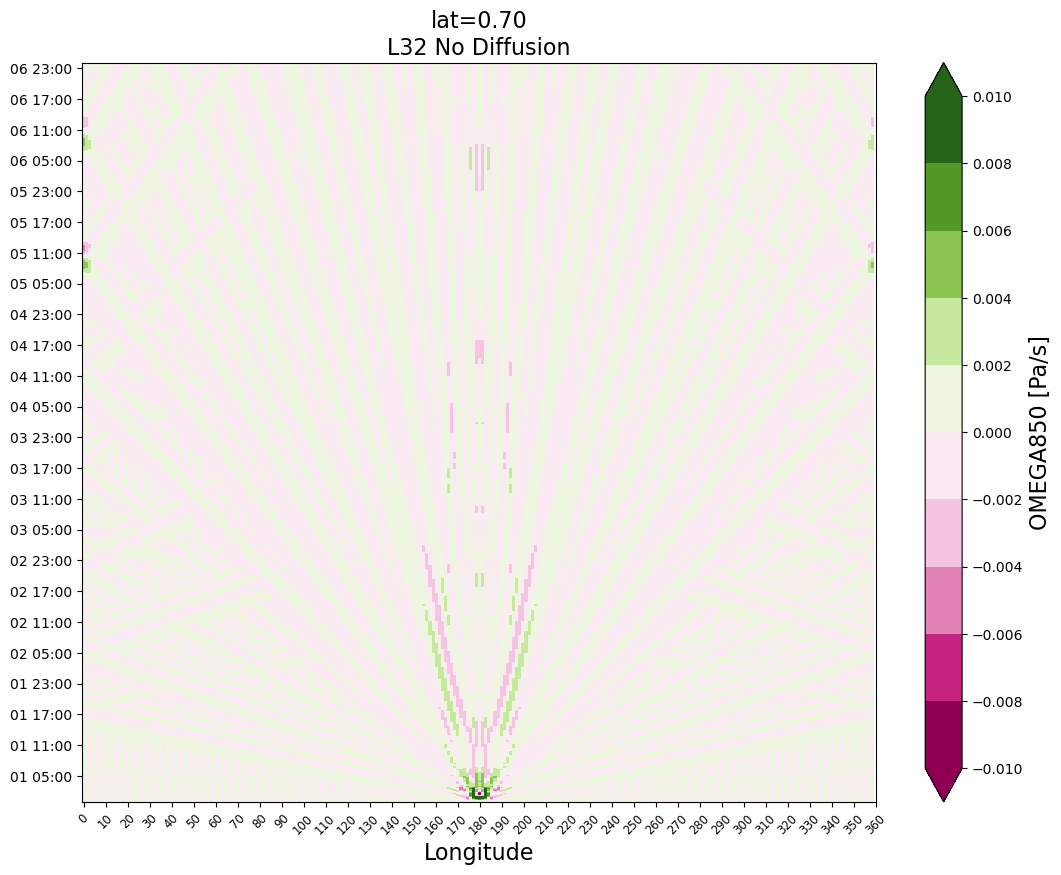

In [47]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.01, 0.01, num=11)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller3(ax, L32_no_diffusion.OMEGA850, lat_value, cmap, norm, clevels, "L32 No Diffusion", "OMEGA850 [Pa/s]")

[-0.01  -0.008 -0.006 -0.004 -0.002  0.     0.002  0.004  0.006  0.008
  0.01 ]


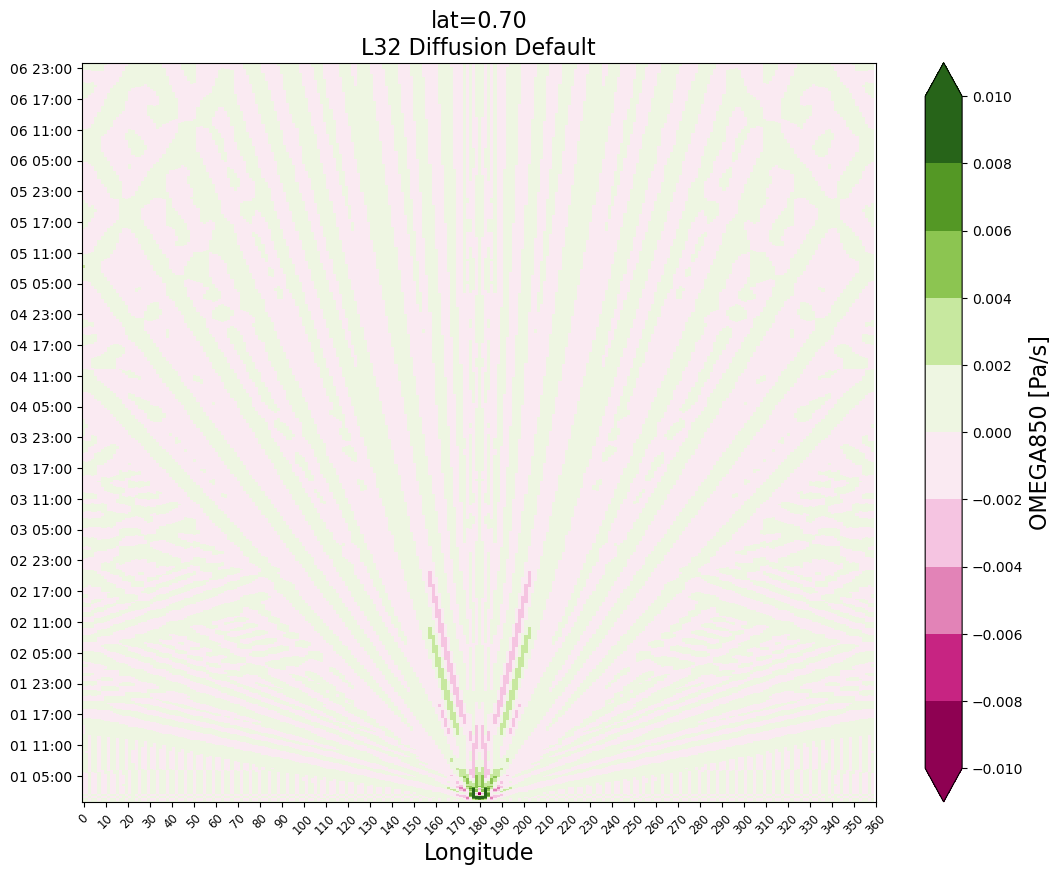

In [48]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.01, 0.01, num=11)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller3(ax, L32_diffusion_default.OMEGA850, lat_value, cmap, norm, clevels, "L32 Diffusion Default", "OMEGA850 [Pa/s]")

[-0.01  -0.008 -0.006 -0.004 -0.002  0.     0.002  0.004  0.006  0.008
  0.01 ]


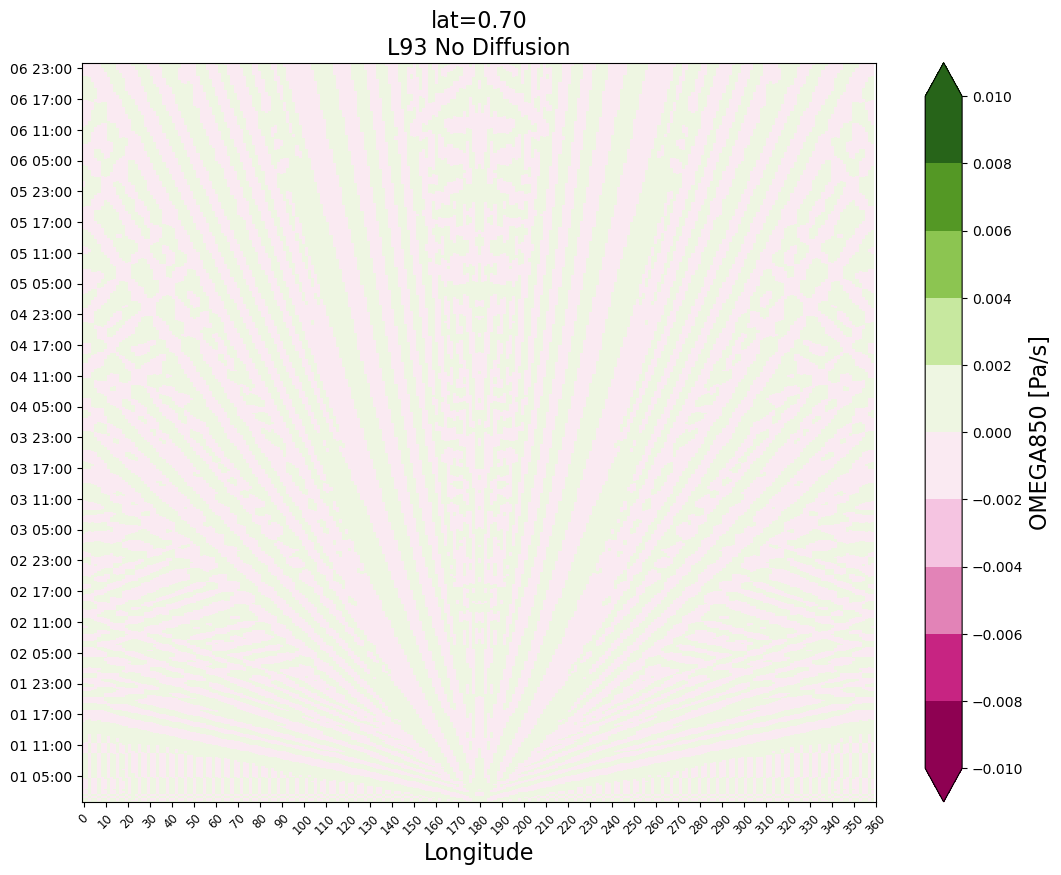

In [49]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.01, 0.01, num=11)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller3(ax, L93_no_diffusion.OMEGA850, lat_value, cmap, norm, clevels, "L93 No Diffusion", "OMEGA850 [Pa/s]")

[-0.01  -0.008 -0.006 -0.004 -0.002  0.     0.002  0.004  0.006  0.008
  0.01 ]


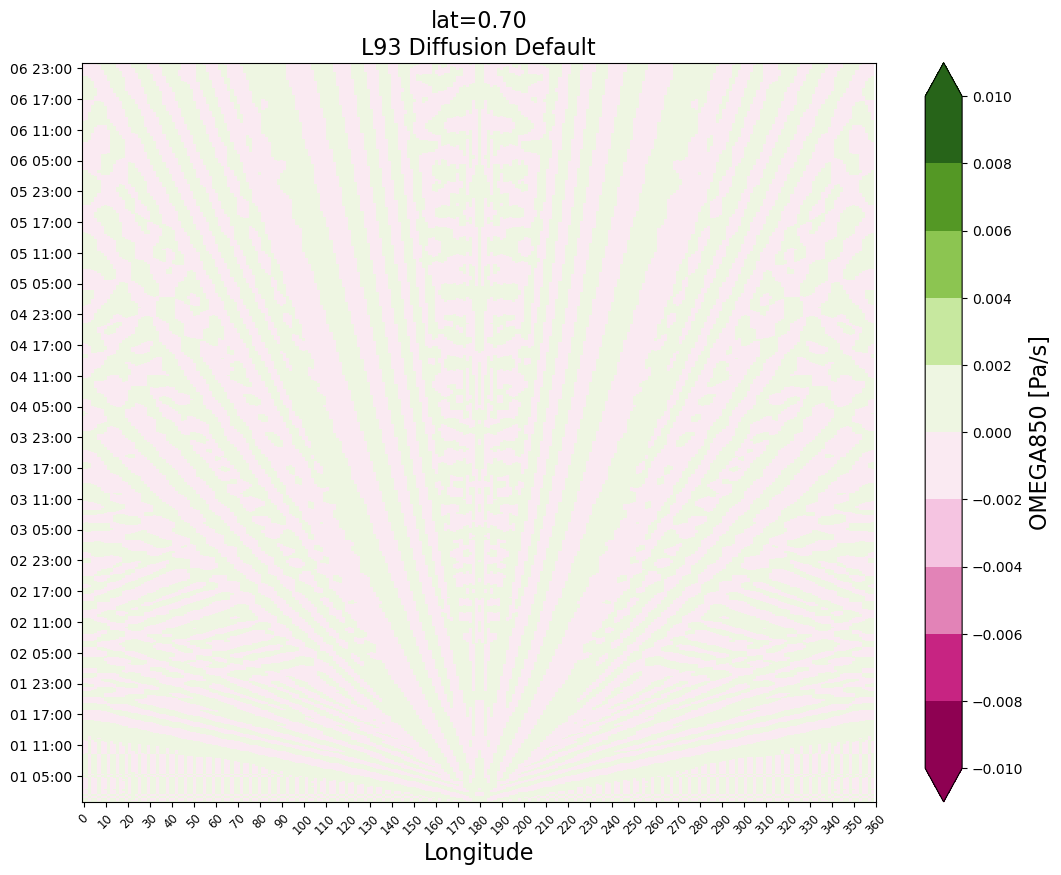

In [50]:
# figure and axes
fig, ax = plt.subplots(figsize=(12.8, 9.6))

# plot parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
clevels = np.linspace(-0.01, 0.01, num=11)
print(clevels)
norm = BoundaryNorm(clevels, ncolors=cmap.N)

Hovmoller3(ax, L93_diffusion_default.OMEGA850, lat_value, cmap, norm, clevels, "L93 Diffusion Default", "OMEGA850 [Pa/s]")